# 03 · Analyse the class map vs the ground truth
### DINO-4DSTEM tutorials

Now that we have a trained model (notebook `02`), we look at what it found and
**measure how good it is** against the WS2 ground truth:

1. run the model -> a **class map**,
2. **ground truth vs result** (accuracy, ARI, NMI, per-class **IoU**, agreement map),
3. the **confusion matrix**,
4. the **cosine-similarity matrix** between classes (how distinct they are),
5. the **per-class diffraction** (what each class actually is).

Uses the same tested helpers in `ws2_utils.py`.

In [1]:
import os, numpy as np, json
import ws2_utils as wu
wu.add_src_to_path(); wu.preimport()   # import analysis modules BEFORE inline
%matplotlib inline
import matplotlib.pyplot as plt

ex = wu.find_ws2_example(); ck = wu.find_ws2_checkpoint()
cube = np.load(os.path.join(ex, 'phantom.cube.npy'), mmap_mode='r')
gt   = np.load(os.path.join(ex, 'phantom.classmap_main.npy'))   # ground truth
Ny, Nx = gt.shape
print('phantom:', os.path.basename(ex))
print('checkpoint:', os.path.basename(ck))

phantom: WS2_example_20260709_215935
checkpoint: synth_finite2


## 1 · Run the model -> a class map

`run_dino_inference` loads the trained checkpoint, runs each diffraction pattern
through it, and reshapes the assignments into a 2-D **class map**. It reuses the
exact crop / polar-mask / vmax the model was trained with (read from the run's
config).

We load the model's already-evaluated result here for speed and reproducibility.
To regenerate it from the checkpoint yourself, pass `use_cache=False` (runs
`infer_scan`, ~45 s on CPU).

In [2]:
r = wu.run_dino_inference(os.path.join(ex, 'phantom.cube.npy'), ck,
                          scan_shape=(Ny, Nx), use_cache=True)
class_map = r['class_map']
print('active classes K =', r['K'], '| cached =', r['cached'])
print('inference params:', {k: r['params'][k] for k in
      ['vmax', 'center_crop_size', 'polar_mask_cols', 'center_mask_radius']})

active classes K = 4 | cached = True
inference params: {'vmax': 50.0, 'center_crop_size': 135, 'polar_mask_cols': 30, 'center_mask_radius': 15}


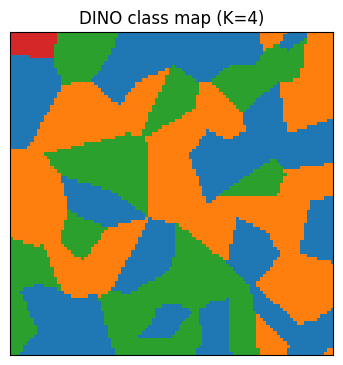

In [3]:
# the DINO class map on its own
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.imshow(class_map, cmap=wu.class_palette(r['K']), interpolation='nearest')
ax.set_title(f'DINO class map (K={r["K"]})'); ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 2 · Ground truth vs result

We **Hungarian-align** the predicted class ids to the ground-truth ids (the model
is unsupervised, so its class numbers are arbitrary), then score. Green in the
agreement panel = correct pixel.

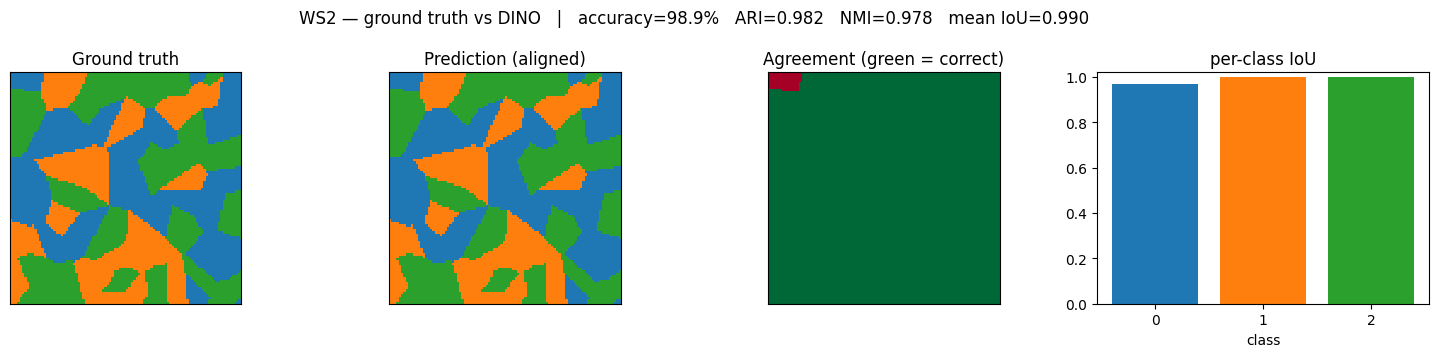

accuracy = 98.89%   ARI = 0.982   NMI = 0.978   mean IoU = 0.990
  class 0: IoU=0.970  F1=0.985  N=3376
  class 1: IoU=1.000  F1=1.000  N=2519
  class 2: IoU=1.000  F1=1.000  N=3321


In [4]:
score = wu.align_and_score(gt, class_map)
fig = wu.plot_gt_vs_pred(gt, score, title='WS2 — ground truth vs DINO')
plt.show()
print(f"accuracy = {score['accuracy']*100:.2f}%   ARI = {score['ARI']:.3f}   "
      f"NMI = {score['NMI']:.3f}   mean IoU = {score['mean_IoU']:.3f}")
for p in score['per_class']:
    print(f"  class {p['gt']}: IoU={p['IoU']:.3f}  F1={p['f1']:.3f}  N={p['N']}")

## 3 · Confusion matrix

Rows = ground-truth class, columns = predicted class (aligned). A near-diagonal
matrix means each true class maps cleanly to one predicted class.

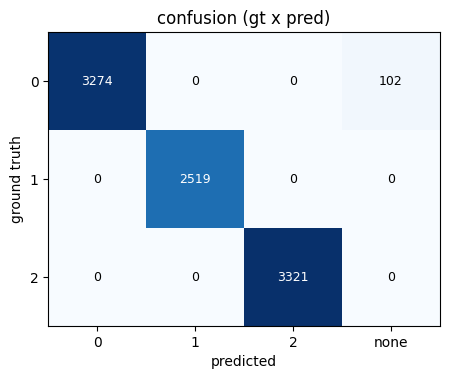

In [5]:
conf = score['confusion']                 # (K_gt, K_gt+1); last col = unassigned
K = score['K_gt']
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(conf, cmap='Blues')
ax.set_xticks(range(conf.shape[1]))
ax.set_xticklabels([str(i) for i in range(K)] + ['none'])
ax.set_yticks(range(K)); ax.set_xlabel('predicted'); ax.set_ylabel('ground truth')
for i in range(K):
    for j in range(conf.shape[1]):
        ax.text(j, i, int(conf[i, j]), ha='center', va='center',
                color='white' if conf[i, j] > conf.max()/2 else 'black', fontsize=9)
ax.set_title('confusion (gt x pred)'); plt.tight_layout(); plt.show()

## 4 · Cosine-similarity matrix

How distinct are the classes in the model's own embedding space? Each entry is
the cosine similarity between two classes' mean embeddings. Off-diagonal values
near 0 (or negative) = well-separated classes.

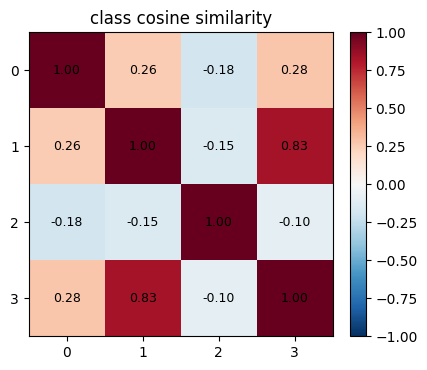

In [6]:
cos = wu.cosine_matrix(r['embeds'], r['assigns'], r['K'])
fig, ax = plt.subplots(figsize=(4.4, 3.8))
im = ax.imshow(cos, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(cos.shape[0]):
    for j in range(cos.shape[1]):
        ax.text(j, i, f'{cos[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_xticks(range(cos.shape[0])); ax.set_yticks(range(cos.shape[0]))
ax.set_title('class cosine similarity'); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 5 · What each class actually is

The **mean diffraction pattern of each predicted class** — averaging over a class
(all its in-plane rotations) turns the Bragg spots into rings, and each
orientation gives a distinct fingerprint.

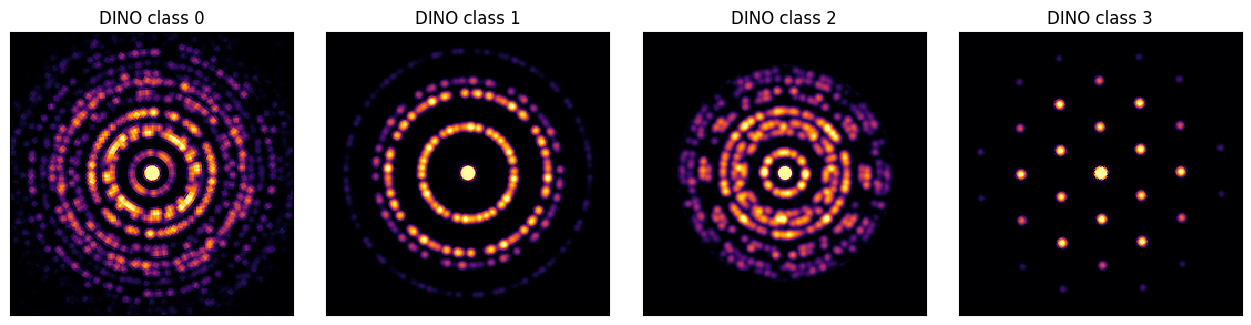

In [7]:
cmd = wu.class_mean_diffraction(cube, class_map, max_per_class=300)
fig, ax = plt.subplots(1, len(cmd), figsize=(3.2*len(cmd), 3.2))
ax = np.atleast_1d(ax)
for a, (cls, dp) in zip(ax, sorted(cmd.items())):
    wu.logshow(a, dp); a.set_title(f'DINO class {cls}')
plt.tight_layout(); plt.show()

### Done

The unsupervised model recovered the 3 WS2 orientations at **~99% accuracy /
ARI ~0.98**, with clean per-class diffraction and well-separated embeddings —
despite never being told the labels, and despite the random in-plane rotations.

**Next -> `04_NMF_kmeans.ipynb`**: run the classical NMF + KMeans baseline and
compare it to DINO and the ground truth.